17 · Metapaths and the 15-minute city

The mechanism the clustering workflow of notebook 18 rests on.

A spatial graph encodes direct proximity: this POI is next to this street
segment. A *metapath* is a relation built through intermediate steps, so
"restaurant A touches segment 7, touches segment 8, touches bar B" becomes a
direct edge **restaurant A → bar B** labeled with what it cost. City2Graph
offers two:

- `add_metapaths()`: walks a given sequence of relations, aggregating
  attributes along the way. Controlled by the number of hops.
- `add_metapaths_by_weight()`: connects two nodes if a path exists whose total
  weight stays under a threshold. With travel time as the weight and the
  threshold at 900 s, this is the 15-minute city.

## 0 · Setup

In [1]:
import pathlib
import sys
import time


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import city2graph as c2g
import geopandas as gpd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

ox = nb.osmnx()

CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600
METRIC_CRS = "EPSG:25830"

# 4.8 km/h is the pedestrian speed transport authorities assume.
SPEED_MS = 4.8 * 1000 / 3600
THRESHOLD_S = 900

## 1 · The street network as a graph of connectors

Nodes are intersections (*connectors*, in the Overture vocabulary), edges are
the segments, weighted by walking time.

In [2]:
G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="walk", simplify=True)
nodes_ox, edges_ox = ox.graph_to_gdfs(G)

connectors = nodes_ox.to_crs(METRIC_CRS)[["geometry"]]
connectors.index.name = "connector_id"

# OSMnx indexes by (u, v, key) to allow parallel segments; city2graph expects
# (source, target), so keep the shortest of each pair.
segments = (edges_ox.to_crs(METRIC_CRS).reset_index()
            .sort_values("length")
            .drop_duplicates(subset=["u", "v"])
            .set_index(["u", "v"])[["length", "geometry"]])
segments["travel_time"] = segments["length"] / SPEED_MS

print(f"connectors {len(connectors):>6}")
print(f"segments   {len(segments):>6}")
print(f"walking time per segment: median {segments['travel_time'].median():.0f} s, "
      f"max {segments['travel_time'].max():.0f} s")

connectors   1472
segments     4354
walking time per segment: median 16 s, max 195 s


## 2 · Dual graph: `dual_graph()`

The preliminary step for the "by hops" metapath. Each segment becomes a node,
two segments connect if they share an intersection, so a three-hop path in the
dual is a route along three streets.

In [3]:
dual_nodes, dual_edges = c2g.dual_graph((connectors, segments))

print(f"dual: {len(dual_nodes)} nodes (= primal segments), "
      f"{len(dual_edges)} edges (= shared intersections)")
check("the dual has one node per segment", len(dual_nodes) == len(segments))

dual: 4354 nodes (= primal segments), 21744 edges (= shared intersections)
[PASS] the dual has one node per segment


True

> **About the equivalent operator.**
> `bpy.ops.scigraphs.create_street_dual_graph()` builds the dual from an OSMnx
> `MultiDiGraph` indexed by `(u, v, key)` and drops `key`, the level that
> distinguishes parallel segments (roundabouts, dual carriageways). Two dual
> nodes then share an identifier, the later `merge` calls multiply rows and the
> metapath counts inflate. `dual_graph()` has an `edge_id_col=` parameter for a
> stable identifier; the operator does not use it. This cell deduplicates on
> `(u, v)` first.

## 3 · The amenities, and the bridge to the street

`bridge_nodes()` hooks each POI to its nearest intersection. Without it the
two layers live in the same space but in separate graphs.

In [4]:
pois = ox.features_from_point(
    CENTER,
    tags={"amenity": ["restaurant", "cafe", "bar", "pub", "cinema", "theatre"]},
    dist=RADIUS_M)
pois = pois[pois.geometry.geom_type == "Point"]
pois = pois.to_crs(METRIC_CRS)[["amenity", "geometry"]].reset_index(drop=True)
pois.index = [f"poi_{i}" for i in range(len(pois))]
pois.index.name = "poi_id"

print(f"{len(pois)} amenities")
print(pois["amenity"].value_counts().to_string())

395 amenities
amenity
restaurant    243
cafe          100
bar            31
pub            18
theatre         2
cinema          1


In [5]:
_, bridges = c2g.bridge_nodes(
    {"amenity": pois[["geometry"]], "connector": connectors},
    proximity_method="knn", k=1)

print("relations created by bridge_nodes:")
for key, gdf in bridges.items():
    print(f"  {key}  ->  {len(gdf)} edges")

relations created by bridge_nodes:
  ('amenity', 'is_nearby', 'connector')  ->  395 edges
  ('connector', 'is_nearby', 'amenity')  ->  1472 edges


In [6]:
nodes_dict = {"amenity": pois[["geometry"]], "connector": connectors}
edges_dict = {
    ("connector", "is_connected_to", "connector"):
        segments[["travel_time", "geometry"]],
    ("amenity", "is_nearby", "connector"):
        bridges[("amenity", "is_nearby", "connector")],
}

# The POI to street hop costs time too, from the straight-line distance to the
# connector: short, for a one-neighbor kNN hookup.
bridge_gdf = edges_dict[("amenity", "is_nearby", "connector")]
edges_dict[("amenity", "is_nearby", "connector")] = bridge_gdf.assign(
    travel_time=bridge_gdf.geometry.length / SPEED_MS)

nb.describe_hetero(nodes_dict, edges_dict)

nodes
  amenity                     395 Point
  connector                  1472 Point
edges
  connector -> is_connected_to -> connector              4354
  amenity -> is_nearby -> connector                       395


{'layers': {'amenity': 395, 'connector': 1472},
 'relations': {"('connector', 'is_connected_to', 'connector')": 4354,
  "('amenity', 'is_nearby', 'connector')": 395}}

## 4 · The 15 minutes: `add_metapaths_by_weight()`

Dijkstra from each amenity, with a direct edge to every amenity reachable in
under `threshold` seconds of `weight`. `endpoint_type="amenity"` restricts the
new edges to that type: intersections are transit, not destination.

In [7]:
# add_metapaths_by_weight() mutates the dict it is given and returns that same
# object, so the new relation cannot be found by comparing result to input.
# Note the keys first and pass a copy.
BASE_KEYS = set(edges_dict)

t0 = time.time()
nodes_15, edges_15 = c2g.add_metapaths_by_weight(
    nodes=nodes_dict,
    edges=dict(edges_dict),
    weight="travel_time",
    threshold=THRESHOLD_S,
    endpoint_type="amenity",
    new_relation_name="15_min_walk",
    directed=False,
)
print(f"{time.time() - t0:.1f} s")

new_keys = [k for k in edges_15 if k not in BASE_KEYS]
print("\nnew relations:")
for key in new_keys:
    print(f"  {key}  ->  {len(edges_15[key])} edges")

check("the 15-minute relation has been created", len(new_keys) >= 1)

1.8 s

new relations:
  ('amenity', '15_min_walk', 'amenity')  ->  72753 edges
[PASS] the 15-minute relation has been created


True

A pedestrian accessibility network between amenities: each edge
means "reachable on foot in under 15 minutes" and carries the real path cost,
not the straight-line distance.

In [8]:
key_15 = new_keys[0]
accessibility = edges_15[key_15]

print(f"15-minute edges: {len(accessibility):,}")
print(f"columns: {list(accessibility.columns)}")

weight_col = next((c for c in accessibility.columns
                  if "travel" in c or "weight" in c or "cost" in c), None)
if weight_col:
    print(f"\npath cost ({weight_col}), in seconds:")
    print(accessibility[weight_col].describe().to_string())
    check(f"no path exceeds the threshold of {THRESHOLD_S} s",
          accessibility[weight_col].max() <= THRESHOLD_S + 1e-6,
          f"maximum {accessibility[weight_col].max():.0f} s")

15-minute edges: 72,753
columns: ['travel_time', 'edge_type', 'geometry']

path cost (travel_time), in seconds:
count    72753.000000
mean       451.958438
std        203.666958
min          8.373750
25%        294.864319
50%        444.572574
75%        603.287081
max        899.963831
[PASS] no path exceeds the threshold of 900 s — maximum 900 s


How many amenities each amenity reaches: a measure of local
accessibility that can be carried forward as a node attribute.

In [9]:
import collections

reach = collections.Counter()
for source, target in accessibility.index:
    reach[source] += 1
    reach[target] += 1

degrees = gpd.GeoDataFrame(
    {"reachable_15min": [reach.get(i, 0) for i in pois.index]},
    geometry=pois.geometry, index=pois.index, crs=pois.crs)

print(degrees["reachable_15min"].describe().to_string())
best = degrees["reachable_15min"].idxmax()
print(f"\nbest connected: {best} ({pois.loc[best, 'amenity']}), "
      f"{degrees.loc[best, 'reachable_15min']} amenities within 15 min")

count    395.000000
mean     368.369620
std       43.473197
min       82.000000
25%      369.000000
50%      378.000000
75%      389.000000
max      394.000000

best connected: poi_27 (restaurant), 394 amenities within 15 min


## 5 · Metapaths by hops: `add_metapaths()`

A sequence of relations instead of a cost budget: amenity → connector →
connector → amenity projects pairs of amenities separated by two street
segments. `edge_attr` names the attributes to accumulate, `edge_attr_agg="sum"`
makes the edge carry the total time.

In [10]:
sequence = [
    ("amenity", "is_nearby", "connector"),
    ("connector", "is_connected_to", "connector"),
    ("connector", "is_nearby", "amenity"),
]

t0 = time.time()
nodes_mp, edges_mp = c2g.add_metapaths(
    nodes=nodes_dict,
    edges=dict(edges_dict),      # a copy, because of the in-place mutation
    sequence=sequence,
    new_relation_name="two_hops",
    edge_attr="travel_time",
    edge_attr_agg="sum",
    directed=False,
)
print(f"{time.time() - t0:.1f} s")

new_mp = [k for k in edges_mp if k not in BASE_KEYS]
for key in new_mp:
    print(f"  {key}  ->  {len(edges_mp[key])} edges")

check("the projection by hops produces edges", len(new_mp) >= 1)

0.0 s
  ('amenity', 'two_hops', 'amenity')  ->  471 edges
[PASS] the projection by hops produces edges


True

The last step, `("connector", "is_nearby", "amenity")`, reverses
the relation `bridge_nodes()` created. `directed=False` resolves the inverted
key on its own; `directed=True` would need the return relation created
explicitly.

## 6 · Isochrones: `create_isochrone()`

The geometric counterpart: the area reachable from a point within a cost
budget, instead of edges. `threshold` accepts a sequence and returns one ring
per threshold in a single GeoDataFrame.

In [11]:
G_net = c2g.gdf_to_nx(nodes=connectors, edges=segments)
center_geom = connectors.geometry.iloc[len(connectors) // 2]

isochrones = c2g.create_isochrone(
    graph=G_net,
    center_point=center_geom,
    threshold=[300, 600, 900],       # 5, 10, 15 minutes
    edge_attr="travel_time",
)

print(f"{len(isochrones)} rings")
print(isochrones.drop(columns="geometry").to_string())
print(f"\nCRS: {isochrones.crs}")

check("the isochrones grow with the threshold",
      list(isochrones.geometry.area) == sorted(isochrones.geometry.area),
      "area in m2: " + ", ".join(f"{a:,.0f}" for a in isochrones.geometry.area))

3 rings
   threshold
0      300.0
1      600.0
2      900.0

CRS: EPSG:25830
[PASS] the isochrones grow with the threshold — area in m2: 326,706, 837,417, 1,268,870


True

> **About the equivalent operator.**
> `bpy.ops.scigraphs.c2g_graph_tool_apply()` with `graph_tool_action =
> 'ISOCHRONE'` rebuilds the graph from the Blender mesh, whose vertices are in
> local units and whose edges carry no attribute. The default weight
> `"length"` does not exist there, so NetworkX applies weight 1 everywhere and
> the threshold counts **hops**, not distance or time, while the panel labels
> it as distance. It exposes neither `method=` nor multiple thresholds. Use the
> direct call above, on the graph in projected coordinates.

## 7 · Everything into the viewport

In [12]:
sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(CENTER[0], CENTER[1], scale=0.001, name="Anchor_Metapaths")

obj_net = sg.graphs.from_gdf(
    connectors, segments, name="Pedestrian_Network", ref=anchor,
    coll="C2G_Metapaths", markers={"graph_type": "street_network"})

obj_15 = sg.graphs.from_hetero(
    {"amenity": pois[["geometry"]]},
    {key_15: accessibility},
    name="Accessibility_15min", ref=anchor, coll="C2G_Metapaths",
    markers={"graph_type": "add_metapaths_by_weight",
             "threshold_s": THRESHOLD_S})

obj_degrees = sg.graphs.from_gdf(
    degrees, accessibility, name="Amenities_Reach", ref=anchor,
    coll="C2G_Metapaths")

for obj in (obj_net, obj_15, obj_degrees):
    print(sg.graphs.summary(obj))

check("the 15-minute network is in the scene", obj_15 is not None)

{'object': 'Pedestrian_Network', 'type': 'MESH', 'num_nodes': 1472, 'num_edges': 2176, 'is_directed': False, 'vertices': 1472, 'mesh_edges': 2176, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'edge_length', 'edge_travel_time'], 'graph_type': 'street_network'}
{'object': 'Accessibility_15min', 'type': 'MESH', 'num_nodes': 395, 'num_edges': 72753, 'is_directed': False, 'vertices': 395, 'mesh_edges': 72753, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'layer_id', 'node_id', 'edge_type_id', 'edge_travel_time'], 'layer_names': 'amenity', 'edge_type_names': 'amenity_15_min_walk_amenity', 'graph_type': 'add_metapaths_by_weight'}
{'object': 'Amenities_Reach', 'type': 'MESH', 'num_nodes': 395, 'num_edges': 72753, 'is_directed': False, 'vertices': 395, 'mesh_edges': 72753, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'node_reachable_15min', 'edge_travel_time']}
[PASS] the 15-minute networ

True

The base street network on its own. Straight down through an
orthographic camera, `render_eevee`'s default: a plan of Ciutat Vella, not a
view of it. Notebooks 00 to 07 share one render style, `look='ink'` and its
turbo ramp on a near-black backdrop, so their figures are comparable. The ramp
carries `edge_travel_time`, the seconds to walk that segment at 4.8 km/h.

The top percentile is clipped, as everywhere in the suite where the
distribution is skewed: a few long peripheral segments would otherwise take the
top of the ramp and press every ordinary street into the bottom stop.

edge_travel_time domain: EDGE
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_travel_time  ·  edge_travel_time -> turbo [log]  [0.5264 … 76.95] on Point


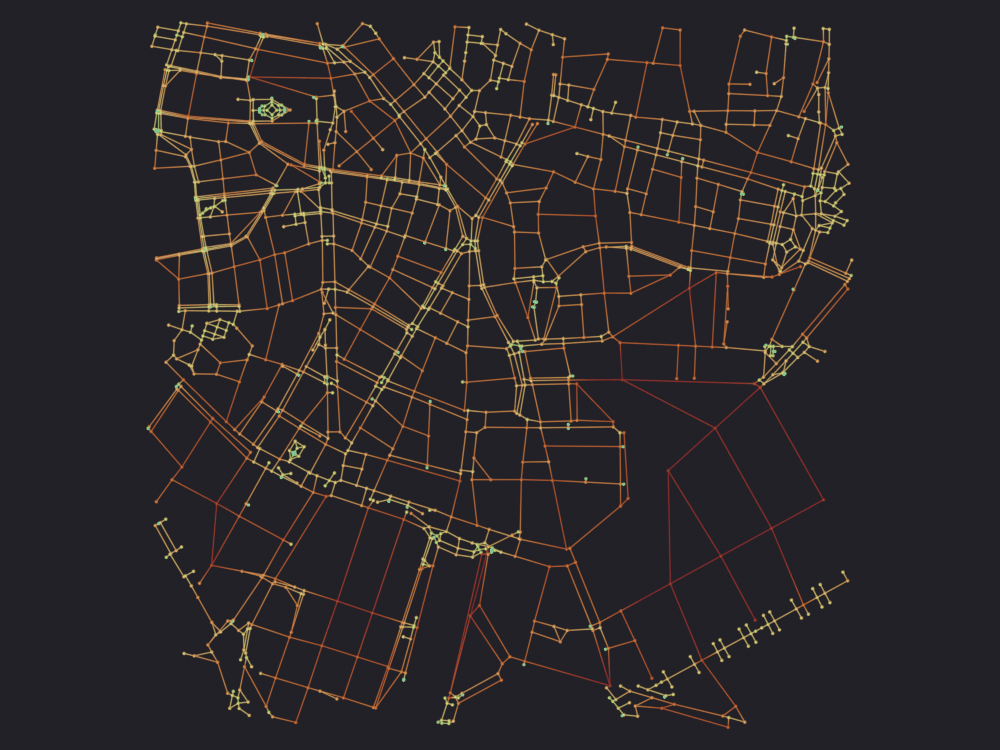

[PASS] 1_pedestrian_network.png legible — 11.0% ink (healthy range 0.5–60%)


In [13]:
print("edge_travel_time domain:",
      sg.render.attribute_domain(obj_net, "edge_travel_time"))

nb.figure(obj_net, "renders/17_metapaths/1_pedestrian_network",
          look='ink', color_attribute="edge_travel_time",
          clip_high_pct=98)

### The same network, on the ground it is a network of

A walking time is a claim about a place, and on a flat background any two
networks look identical, so this figure gets real elevation, buildings and an
aerial photograph.

`terrain_source="auto"` is the only elevation fetch in the eight notebooks. It
probes `open-elevation` with a short timeout, because a dead public endpoint
otherwise costs two or three minutes of 30-second timeouts, then falls back
loudly to a flat plane. `ctx["real_elevation"]` is `True` only for a surface
built from fetched elevations.

`buildings_gdf` is left out, so footprints are downloaded here. The call prints
the tagged fraction: in central Valencia about one in six carries a `height` or
a `building:levels`, the rest get the median of those that do. The skyline is a
convention, not a survey.

`imagery="ESRI_IMAGERY"` at zoom 17 costs 36 tiles over a 1.2 km box, about
seven tenths of a second cold and a quarter of that cached. This box is larger;
the call prints the count fetched, each zoom step quadruples it, and the fetch
refuses over 256 tiles. The attribution it returns is a license term.

Context radius is 1.5x the study radius: notebook 13 shows an orthographic
camera on a square graph in a 4:3 frame needs ground about 1.4 times the
graph's half-extent to fill it.

`check_alignment()` measures mesh against graph, and draping an image moves no
vertex, so a basemap for the wrong kilometer passes it. The only test is
whether the network runs along the streets in the photograph.

In [14]:
t0 = time.time()
ctx = sg.context.add_context(obj_net, CENTER, RADIUS_M * 1.5, anchor,
                             terrain_source="auto",
                             imagery="ESRI_IMAGERY", imagery_zoom=17)
print(f"context built in {time.time() - t0:.1f} s")
print("real elevation:", ctx["real_elevation"])
print("real imagery  :", ctx["real_imagery"])
sg.context.report(ctx["objects"])

check("the context is aligned with the graph",
      bool(ctx["alignment"] and ctx["alignment"]["ok"]),
      "a wrong anchor puts the buildings in another kilometer")

  open-elevation probe: unreachable (10.16 s, ReadTimeout: HTTPSConnectionPool(host='api.open-elevation.com', port=443): Read timed out. (read timeout=10.0))
  FALLING BACK TO A FLAT PLANE: open-elevation is unreachable (ReadTimeout: HTTPSConnectionPool(host='api.open-elevation.com', port=443): Read timed out. (read timeout=10.0)). This is NOT elevation data.
Creating terrain mesh: 2x2 vertices
Terrain mesh created: 4 vertices, 1 faces
  flat ground, 1800 x 1800 m (no elevation data)
  4772 footprints -> 73132 faces, 136708 vertices
  heights: 1826 from OSM tags (38.3%), the rest at 21.0 m (median of tagged)
  Esri · Satellite (World Imagery): 8x8 = 64 tiles at zoom 17, 2048x2048 px
  64 already cached, 0 to fetch (~0.0 MB)
Basemap: ESRI_IMAGERY z=17 → 8×8=64 tiles (2048×2048 px)
Basemap saved: /tmp/scigraphs_basemaps/_composites/basemap_esri_imagery_z17_1787036082.png (1955×1954 px, 0/64 failed tiles)
scigraphs-utils available - Graphviz layouts enabled
  Esri · Satellite (World Image

True

The credit line for the imagery. A failed fetch puts the matte
material back and says so, so `real_imagery` above is what to trust.

In [15]:
sg.context.attribution(ctx["objects"])

  Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community


['Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community']

Only the straight-down view is kept: from any other angle a tall
block leans across the streets behind it and the network stops being
measurable. Relief and height have their own notebook.

`settle()` moves the whole context down by one shared offset so the *ground*,
not the tallest roof, clears the graph plane by a meter. Straight down that
shows as a roof occluding the edge beneath it: not an artifact, a building.

The near-black look was measured rather than assumed: once real ground fills
the frame the graph competes with a photograph. Same camera twice, with and
without the network, so the graph is exactly the pixels the two frames differ
in. Tube interiors sit 45.5 units of ΔE from the ground beneath them, against
46.7 under the warm-gray look, and the share lost in the photograph (under
ΔE 10) falls from 7.4 % to 6.6 %. Fast segments read at 36.8 ΔE, slow ones at
35.9, both about one percent buried. The slowest segments are dark red rather
than near-white now, so they no longer announce themselves; look for them in
the south-east corner.

  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_travel_time  ·  edge_travel_time -> turbo [log]  [0.5264 … 76.95] on Point


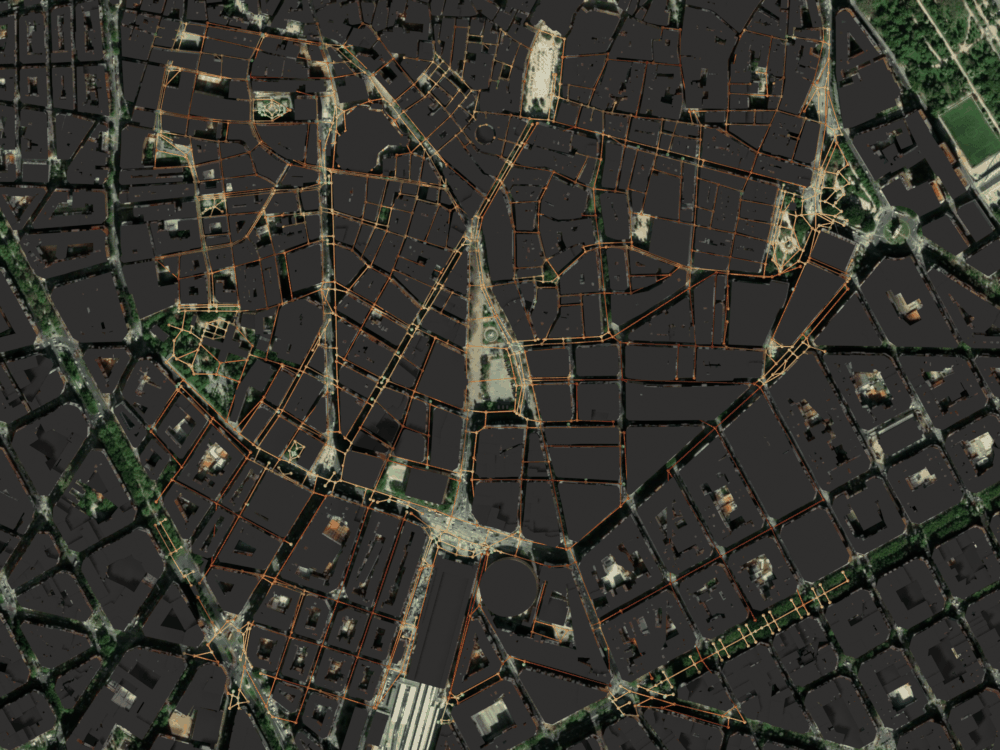

[PASS] 2_network_context.png legible — 93.4% ink (healthy range 0.5–100%)


In [16]:
# The accessibility graphs sit on the same anchor, on top of this one, and
# `isolate=False` would render them too.
for _obj in (obj_15, obj_degrees):
    if _obj is not None:
        _obj.hide_render = True

# Ink ceiling lifted for the usual overhead reason (notebook 13). The floor
# still bites.
path = nb.render(obj_net, "renders/17_metapaths/2_network_context",
                 isolate=False, look='ink',
                 color_attribute="edge_travel_time",
                 clip_high_pct=98, verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

for _obj in (obj_15, obj_degrees):
    if _obj is not None:
        _obj.hide_render = False

In [17]:
if obj_net is not None:
    sg.graphs.visualize(obj_net, node_size=0.004, edge_thickness=0.0015)
if obj_15 is not None:
    sg.graphs.visualize(obj_15, node_size=0.02, edge_thickness=0.002)
    # The two graphs share a plane, and moving the street network down would
    # bury it in the terrain. 0.05 Blender units is 50 m of real ground.
    obj_15.location.z += 0.05
if obj_degrees is not None:
    # The figures' ramp, so the viewport and the PNGs agree.
    sg.graphs.color_by(obj_degrees, "node_reachable_15min", colormap="turbo")

sg.graphs.from_features(isochrones, name="Isochrones", ref=anchor,
                        coll="C2G_Metapaths")
sg.graphs.frame()

  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
  Promoted 2 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_reachable_15min  ·  node_reachable_15min -> turbo [log]  [82 … 394] on Point
Using reference projection: center=(39.469900, -0.376300), scale=0.001
Created 1 object(s) from GeoDataFrame with 3 features


## 8 · The SciGraphs metapath wizard

A shortcut that chains dual + bridges + metapaths in one call. It requires the
active object to be a network imported with `import_osm_graph`, which
registers the `MultiDiGraph` in its internal cache, so the route is through
operators from start to finish.

In [18]:
props_sg = bpy.context.scene.scigraphs
props_c2g = bpy.context.scene.city2graph

props_sg.osmnx_download_method = 'POINT'
props_sg.osmnx_latitude, props_sg.osmnx_longitude = CENTER
props_sg.osmnx_distance = RADIUS_M
props_sg.osmnx_network_type = 'walk'
props_sg.osmnx_simplify = True

result = bpy.ops.scigraphs.import_osm_graph()
print("import_osm_graph ->", result)

net_obj = next((o for o in bpy.data.objects if o.get("is_osmnx")), None)
print("network object:", net_obj.name if net_obj else "(none)")


  Point: (39.46989822387695, -0.37630000710487366), radius: 600m
  Download completed in 1.43s
Total import time: 1.95s
  Nodes: 1,582, Edges: 4,714

Creating OSMnx graph: 1,582 nodes, 4,714 edges...
  Created 1,582 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
  Created 2,337 street edges in 0.33s
Total OSMnx graph creation time: 0.33s
Graph saved to ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_walk.graphml
Graph cached to: ~/.config/blender/5.2/scripts/addons/scigraphs_osmnx_cache/39.4699_-0.3763_walk.graphml
Info: Downloading network from OpenStreetMap (POINT)...
Info: Graph cached as: 39.4699_-0.3763_walk.graphml
Info: Imported: 1582 intersections, 4714 street segments, 147.6 km total
import_osm_graph -> {'FINISHED'}
network object: OSMnx_StreetNetwork


In [19]:
if net_obj is not None:
    props_sg.feat_source = 'OSMNX'
    props_sg.feat_type = 'AMENITY_METAPATH'
    props_sg.feat_nodes_only = True
    props_c2g.c2g_area_method = 'FROM_OSMNX'

    sg.graphs.activate(net_obj)
    print("c2g_load_overture_points ->", bpy.ops.scigraphs.c2g_load_overture_points())

    amenities_obj = next((o for o in bpy.data.objects
                         if o.get("c2g_geometry_kind") == "POINT"), None)
    print("amenities object:", amenities_obj.name if amenities_obj else "(none)")

    if amenities_obj is not None:
        props_c2g.metapath_amenities_object = amenities_obj
        props_c2g.metapath_hops = 3
        props_c2g.metapath_k_neighbors = 1
        props_c2g.metapath_amenity_limit = 200
        props_c2g.metapath_visualize_limit = 500

        sg.graphs.activate(net_obj)
        print("compute_metapaths_wizard ->",
              bpy.ops.scigraphs.compute_metapaths_wizard())

        for obj in bpy.data.objects:
            if obj.get("is_metapath_result") or obj.get("is_street_dual"):
                print(" ", sg.graphs.summary(obj))

[c2g] Area resolved from OSMnx graph 'OSMnx_StreetNetwork': (39.476058540922004, 39.461390140524934, -0.3681065890664948, -0.3838947308028426)
Downloaded 557 features from bbox
Filtered to node elements: 547 features
Using reference projection: center=(39.470939, -0.377165), scale=0.0010000000474974513
Created 1 object(s) from GeoDataFrame with 547 features
Info: Area: OSMnx graph 'OSMnx_StreetNetwork'
Info: Downloading AMENITY_METAPATH as points from OSMNX
Info: Created 1 point object(s)
c2g_load_overture_points -> {'FINISHED'}
amenities object: osmnx_amenity_metapath_Centroids
✓ Dual graph has 'is_intersection' attribute (setup visual compatible)
Graph attributes: num_nodes=4714, num_edges=23709, nodes_data=present, edges_data=present
Info: Creating street dual graph...
Info: Dual graph: 4714 nodes, 23709 edges
Info: Street dual graph created: 4714 segments as nodes, 23709 connections (0.71s)
Info: Bridging amenities to street segments...
Info: Using 200 amenities
Info: Created 200 b

~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/scigraphs_core/city2graph/metapaths.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.
  dual_nodes_gdf, dual_edges_gdf = c2g.dual_graph((street_primary_nodes, street_primary_edges))
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/city2graph/utils.py:1824: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dual_nodes["geometry"] = dual_nodes.geometry.centroid
~/.config/blender/5.2/extensions/.local/lib/python3.13/site-packages/scigraphs_core/city2graph/metapaths.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS

## 9 · Saving

In [20]:
output_dir = nb.out("05_metapaths")
output_dir.mkdir(parents=True, exist_ok=True)

sg.graphs.save_gdf(accessibility, output_dir / "accessibility_15min.gpkg")
sg.graphs.save_gdf(degrees, output_dir / "amenities_reach.gpkg")
sg.graphs.save_gdf(isochrones, output_dir / "isochrones.gpkg")

print("written to", nb.rel(output_dir))
for f in sorted(output_dir.iterdir()):
    print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/05_metapaths
   accesibilidad_15min.gpkg 15720 kB
   accessibility_15min.gpkg 15720 kB
   amenities_alcance.gpkg 139 kB
   amenities_reach.gpkg 139 kB
   isochrones.gpkg 98 kB
   isocronas.gpkg 98 kB


## The hairball, and thinning it honestly

What matters is where the sparsification happens. `sg.preview.backbone()` thins
*without touching the data*, by setting `scene.scigraphs_preview_backbone_*`,
read only while the add-on's GPU renderer fills its buffers. The Geometry Nodes
path EEVEE draws through has no equivalent and instances a tube per mesh edge,
so `draw_eevee()` with a GPU backbone set draws every edge anyway.
`SciGraphs.api.thin` moves the rule into Python: rank each node's incident edges by an edge
attribute, keep the top k, build a filtered copy. That copy is an ordinary
graph object, so EEVEE needs no special case and the thinning survives into
anything saved from it.

The three figures below use `obj_degrees`, not `obj_15`. Both hold the same 395
amenities and 72,753 edges, and both now carry the numeric columns:
`create_native_heterograph_from_dicts` takes the union of numeric columns over
the layers and relations, so `obj_15` has `edge_travel_time` too. It did not
always — it wrote `layer_id` and `edge_type_id` and nothing else, which left no
attribute on it to rank a backbone by or color by. The homogeneous copy is
still the one used here, because a heterograph fills a column absent from a
relation with 0.0 and a zero travel time is not a measurement.

`look='ink'` for all three, so the ramp is the only thing that changes:
walking time on the first two, reach count on the third.

In [21]:
print(f"total edges: {obj_degrees.get('num_edges'):,}")
print("edge attributes on the homogeneous copy:",
      [n for n, d, _ in sg.graphs.attributes(obj_degrees) if d == 'EDGE'])
print("edge attributes on the heterogeneous one:",
      [n for n, d, _ in sg.graphs.attributes(obj_15) if d == 'EDGE'])

# What the GPU filter actually ranks with. The add-on never raises this, so it
# is worth printing rather than assuming.
for label, target in (("homogeneous", obj_degrees), ("heterogeneous", obj_15)):
    probe = sg.thin.gpu_weights(target, "travel_time")
    print(f"  backbone(attribute='travel_time') on the {label} copy reads "
          f"{probe['name'] or 'NOTHING, it ranks uniformly'}")
    probe_absent = sg.thin.gpu_weights(target, "no_such_column")
    print(f"  and a name that does not exist reads "
          f"{probe_absent['name'] or 'NOTHING, as it should'}")

total edges: 72,753
edge attributes on the homogeneous copy: ['.edge_verts', 'edge_travel_time']
edge attributes on the heterogeneous one: ['.edge_verts', 'edge_type_id', 'edge_travel_time']
  backbone(attribute='travel_time') on the homogeneous copy reads edge_travel_time
  and a name that does not exist reads NOTHING, as it should
  backbone(attribute='travel_time') on the heterogeneous copy reads edge_travel_time
  and a name that does not exist reads NOTHING, as it should


Read those lines. `sg.preview.backbone(attribute=…)` takes a
*GeoDataFrame* column name, but the filter resolves it against the **mesh**,
where `_write_edge_attributes` stored `travel_time` as `edge_travel_time`.
`simplify.edge_weight_candidates` tries the prefixed form as well as the bare
one, so the name resolves and the ranking is on real walking times.

It did not always. The bare name missed, the lookup fell through to a column
literally called `weight`, missed again, returned `None` — and `backbone_mask`
reads `None` as uniform weights. Uniform weights make top-k a tie at every
node, so what survived was whatever the stable sort reached first: mesh order,
drawn as though it were a measurement, with nothing raised. An earlier version
of the backbone figure below was drawn that way. The second probe above is why
the diagnostic is still here after the fix: a name that is genuinely absent has
to keep reading as absent, not as ranked.

`TOPK` also keeps the edges of **largest** weight, and on a travel time the
largest is the slowest, so "the k strongest edges of each node" is the k
*least* accessible destinations. `sense='low'` gives the reading this notebook
has been claiming all along.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_travel_time  ·  edge_travel_time -> turbo [log]  [8.374 … 859.8] on Point


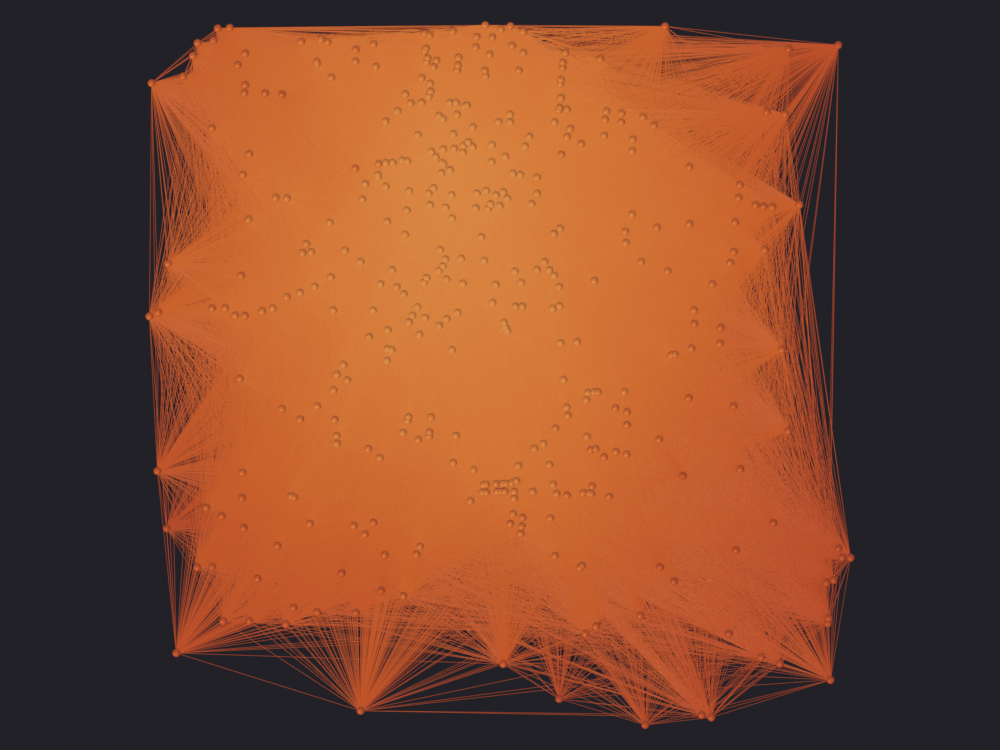

  accessibility_15min unfiltered: 58.6% ink
[PASS] the 15-minute graph comes out saturated, as expected — almost complete within the study radius


True

In [22]:
# Unfiltered, as the baseline for the next figure. The legibility threshold is
# left open on purpose: this figure is meant to fail it.
hairball_path = nb.render(
    obj_degrees, "renders/17_metapaths/4_accessibility_15min",
    look='ink', color_attribute="edge_travel_time", clip_high_pct=98,
    verbose=False)
nb.show(hairball_path)
hairball_ink = nb.ink(hairball_path)
print(f"  accessibility_15min unfiltered: {hairball_ink * 100:.1f}% ink")
check("the 15-minute graph comes out saturated, as expected",
      hairball_ink > 0.5, "almost complete within the study radius")

### When the graph is a hairball

A solid mass of lines with the nodes buried in it. This is the data, not a
drawing failure: within a 600 m radius almost any amenity reaches almost any
other in 15 minutes, so the graph is nearly complete.

> It says less about the neighborhood than it looks. Notebook 09 measures
> the eccentricity of this network from the same center and gets **858 s**, so
> a 900-second budget reaches every node there is, and would in any city given
> a 600 m extract. The completeness is a property of the *download radius*,
> not of Ciutat Vella. A 15-minute claim only means something when the study
> area is larger than 15 minutes across.

Keeping each amenity's *k* cheapest edges gives "the k most accessible
destinations from here", and doing it in the data means the two figures that
follow are the same EEVEE plate as this one with fewer edges.

In [23]:
obj_backbone, report_backbone = sg.thin.graph(
    degrees, accessibility, name="Accessibility_15min_Top3",
    weight=weight_col, k=3, sense='low', ref=anchor, coll="C2G_Metapaths")

  top-3 per node on 'travel_time' (smallest first): 779 of 72,753 edges (1.1%), 0.1% of the total weight
  Accessibility_15min_Top3: 395 nodes, 779 edges


The check that this is the graph the GPU filter would have drawn.
`verify()` reads the mesh of the unthinned object, resolves the weight the way
`edge_weights_raw` does, applies the rule and compares the resulting edge set
against the mesh of the copy, as unordered vertex pairs. The spot check
re-derives a sample of nodes' top-k with a plain `sorted()`, so a wrong rank
cannot pass by agreeing with itself.

In [24]:
verification = sg.thin.verify(obj_backbone, obj_degrees, degrees,
                              accessibility, weight=weight_col, k=3,
                              sense='low')
check("the materialized backbone is the GPU filter's own edge set",
      verification["identical"],
      f"{verification['materialized_kept']:,} edges, "
      f"{verification['only_in_gpu']} missing, "
      f"{verification['only_in_materialized']} extra")
check("and it is ranked by travel time, not uniformly",
      not verification["gpu_uniform"],
      f"weight read as '{verification['gpu_weight_attribute']}'")

  GPU filter would keep     779 of 72,753 mesh edges
  materialized backbone has 779
  identical edge sets:      True
  spot check: 40 nodes, 0 missing an edge strictly in their top 3 (0 tied at the cut, where the choice is the sort's and not the data's)
[PASS] the materialized backbone is the GPU filter's own edge set — 779 edges, 0 missing, 0 extra
[PASS] and it is ranked by travel time, not uniformly — weight read as 'edge_travel_time'


True

What the two `sense` values cost, in edges and in the share of
total walking time they keep. They are different graphs, not two drawings of
one.

  3 cheapest per amenity      779 edges ( 1.1% of 72,753),   0.1% of the total travel time
  3 slowest per amenity     1,021 edges ( 1.4% of 72,753),   2.7% of the total travel time
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_travel_time  ·  edge_travel_time -> turbo [log]  [8.374 … 179.5] on Point


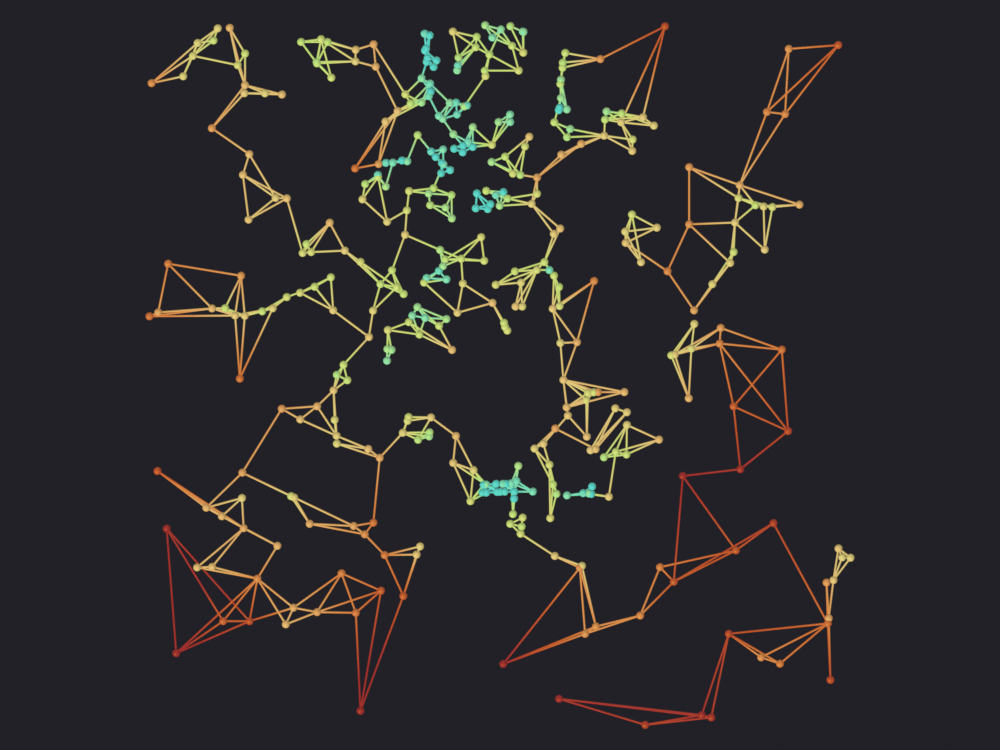

[PASS] 5_accessibility_15min_backbone.png legible — 9.3% ink (healthy range 0.5–60%)


In [25]:
for sense, label in (('low', "3 cheapest per amenity"),
                     ('high', "3 slowest per amenity")):
    _, r = sg.thin.top_k(degrees, accessibility, weight=weight_col,
                         k=3, sense=sense, verbose=False)
    print(f"  {label:<24} {r['kept']:>6,} edges "
          f"({r['kept'] / r['total'] * 100:>4.1f}% of {r['total']:,}), "
          f"{r['weight_frac'] * 100:>5.1f}% of the total travel time")

nb.figure(obj_backbone,
          "renders/17_metapaths/5_accessibility_15min_backbone",
          look='ink', color_attribute="edge_travel_time",
          clip_high_pct=98)

The same graph colored by how many amenities each one reaches.
`k=2` rather than 3, because here the edges are scaffolding: the measurement
is on the nodes and the ramp has to survive on `node_reachable_15min` without
a mat of tubes across it. A POINT attribute puts the colormap on the spheres
and leaves the tubes neutral, the correct way round for a node-valued
quantity.

Almost everything comes back at the top of the ramp: `reachable_15min` runs 82
to 394 out of 395 amenities. The ramp is there for the exception, the pocket at
the south-east edge cut off from the rest and reading cyan against a field of
red, 70 units of ΔE off the backdrop. `LINEAR` normalization is kept for that
reason; `RANK` would spread the colors evenly and make a nearly constant
quantity look like a gradient.

  top-2 per node on 'travel_time' (smallest first): 533 of 72,753 edges (0.7%), 0.1% of the total weight
  Amenities_Reach_Top2: 395 nodes, 533 edges
node_reachable_15min domain: POINT
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_reachable_15min  ·  node_reachable_15min -> turbo [log]  [82 … 394] on Point


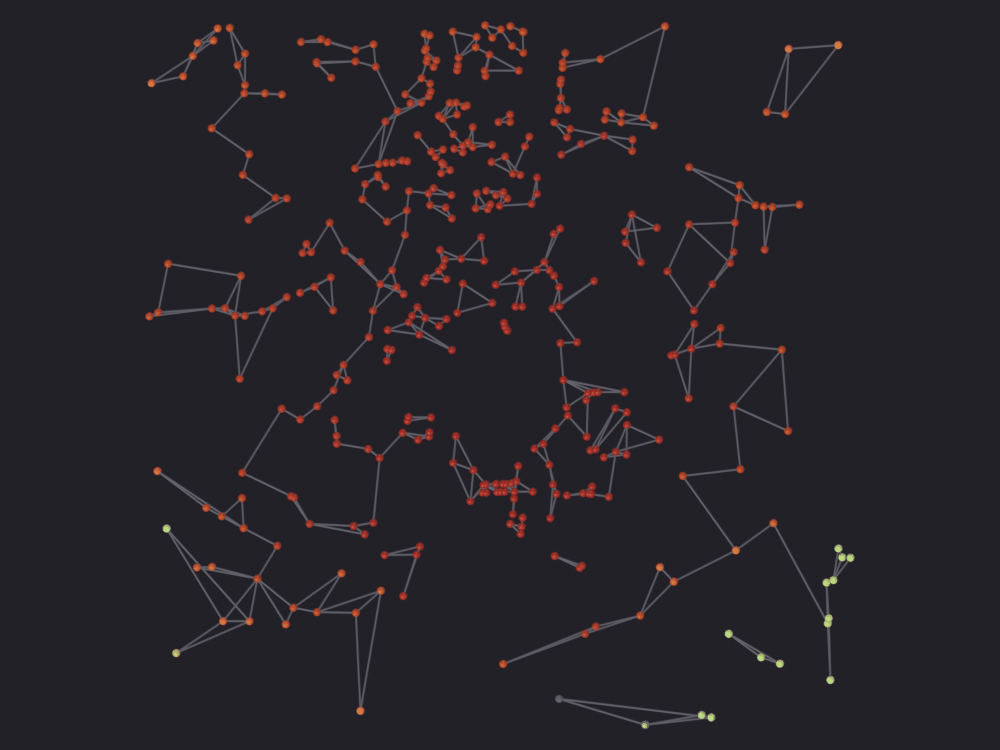

[PASS] 6_amenities_reach.png legible — 6.3% ink (healthy range 0.5–60%)


In [26]:
obj_reach, report_reach = sg.thin.graph(
    degrees, accessibility, name="Amenities_Reach_Top2",
    weight=weight_col, k=2, sense='low', ref=anchor, coll="C2G_Metapaths")

print("node_reachable_15min domain:",
      sg.render.attribute_domain(obj_reach, "node_reachable_15min"))

nb.figure(obj_reach, "renders/17_metapaths/6_amenities_reach",
          look='ink', color_attribute="node_reachable_15min")

## Summary

| Idea | Function | Control |
|---|---|---|
| Project by hops | `add_metapaths(sequence=…)` | length of the sequence |
| Project by cost | `add_metapaths_by_weight(weight=…, threshold=…)` | budget |
| Reachable area | `create_isochrone(threshold=[…])` | one or several rings |

Next: **06 · Functional clustering, end to end**.